# Environement

In [32]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'


import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import entropy

from eci.environment import EnvConfig, Environment

# Local project imports
from eci.plots import plot_belief_trajectory
from eci.utils import (
    _extract_env_data_vectorized,
    generate_observations,
    get_voter_trajectory_data,
)

# Note: the old `eci.voting_system.beliefs` module was merged into
# `eci.voting_system.decisions`. `_get_pref_belief_gap` was renamed
# `_get_belief_preference_gap` and both helpers now take raw arrays
# (mean / precision) instead of the `data` dict.
from eci.voting_system.decisions import (
    _get_belief_preference_gap,
    _get_pref_candidate_gap,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# How observation work?

When you specify a scenario, the function generate observations return a numpy.ndarray (a multi-dimensional array) containing floating-point numbers.

The shape of the array is: $(n\_steps, n\_preference)$.
Axis 0 (Rows): Represents time ($n\_steps$).
Axis 1 (Columns): Represents each specific preference ($n\_nodes$).

Values are strictly between $0.0$ and $1.0$ (clipped at the end of the function). Logic: The data represents synthetic observations (probabilities or rates) following a Beta distribution, potentially affected by shocks or trends and Gaussian noise.

Visual Representation. If you call generate_observations(n_nodes=3, n_steps=5), the resulting matrix looks like this:

$$\begin{bmatrix}
t_0n_0 & t_0n_1 & t_0n_2 \\
t_1n_0 & t_1n_1 & t_1n_2 \\
t_2n_0 & t_2n_1 & t_2n_2 \\
t_3n_0 & t_3n_1 & t_3n_2 \\
t_4n_0 & t_4n_1 & t_4n_2
\end{bmatrix}$$


In [33]:
config = EnvConfig(
    num_voters=50, num_candidates=4, num_preferences=2, scenario=2, num_steps=100
)
NUM_SIMULATIONS = 100

In [34]:
# Initialize environment
env = Environment(config)
env.num_simulations = NUM_SIMULATIONS
env._run_multi_agent_inference()

In [35]:
env.input_data  # (100 timestep, 2 preference)

array([[0.8886775 , 0.74041405],
       [0.88679444, 0.85400351],
       [0.92018658, 0.99589554],
       [0.94491568, 1.        ],
       [0.98822284, 0.82398526],
       [0.95372694, 0.95342312],
       [0.92967468, 0.9514957 ],
       [0.81963616, 1.        ],
       [0.92569351, 0.82740444],
       [0.92557109, 0.89376665],
       [0.85326757, 0.98895505],
       [0.94059411, 0.9360801 ],
       [0.97396244, 0.81055485],
       [1.        , 0.95067401],
       [0.94747272, 0.803921  ],
       [0.88725098, 1.        ],
       [0.97298793, 0.98330951],
       [0.84258736, 1.        ],
       [0.99397118, 0.82667343],
       [1.        , 0.90209044],
       [0.93691711, 0.93108182],
       [0.8443869 , 0.90575601],
       [0.98123073, 0.98816015],
       [0.9246338 , 0.98125812],
       [0.90689485, 1.        ],
       [0.84293942, 0.97545921],
       [0.89582798, 0.95811747],
       [0.94329881, 0.95352411],
       [0.89897148, 0.8968346 ],
       [0.99003402, 0.85366783],
       [0.

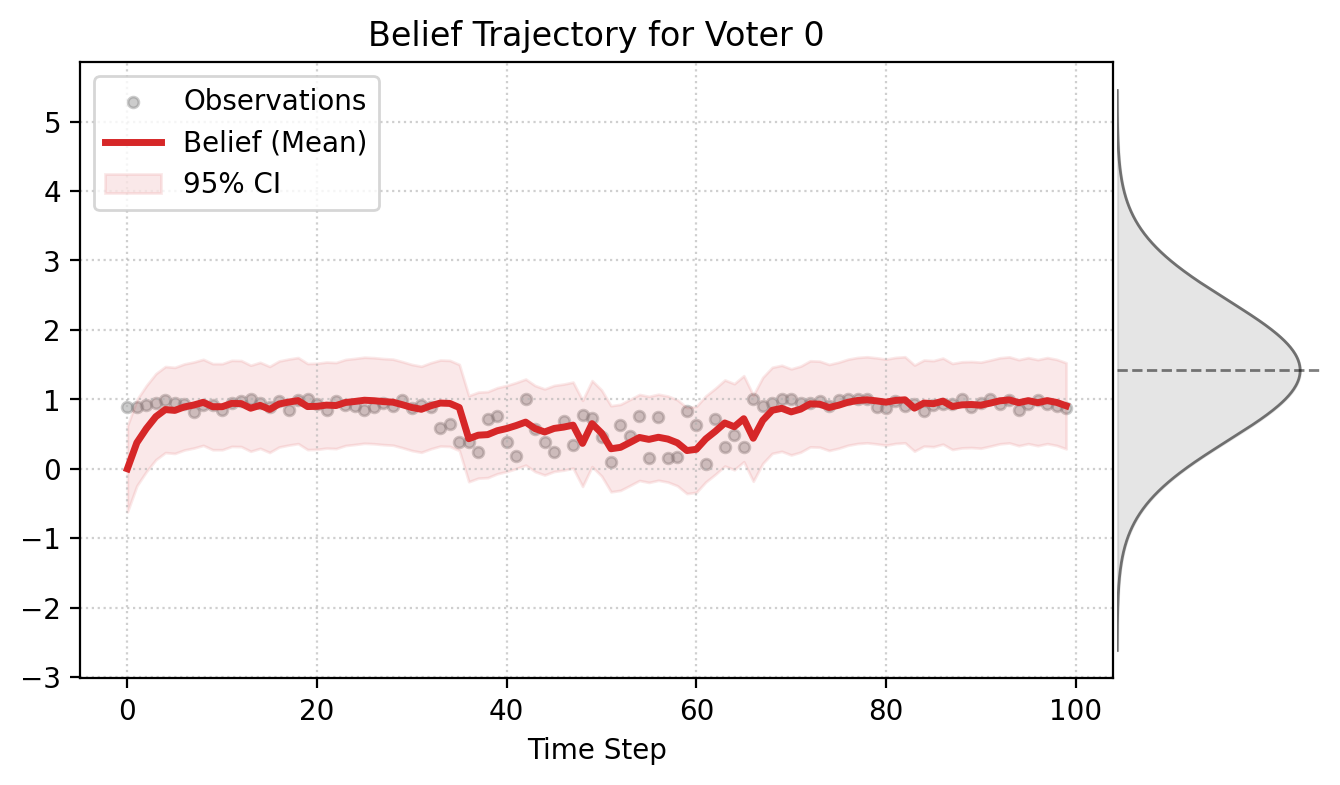

In [36]:
traj_data = get_voter_trajectory_data(env, voter_id=0)
fig, ax1, ax2 = plot_belief_trajectory(**traj_data)

# How to create observations manually?

To replicate the data structure expected by your pipeline without using the generator, you can use NumPy. Here are three ways to do it:

In [37]:
# Example: 3 time steps, 2 nodes
manual_obs = np.array(
    [
        [0.10, 0.95],  # Time t=0: Node 0 is low, Node 1 is high
        [
            0.20,
            0.90,
        ],  # Time t=1   (clamped to [0,1] -- the original 3.20 violated the invariant)
        [0.50, 0.50],  # Time t=2: Both converge
    ]
)

print(f"Shape: {manual_obs.shape}")
# Output: (3, 2) -> (n_steps, n_nodes)

Shape: (3, 2)


In [38]:
# Initialize environment
env = Environment(config)
env.input_data = manual_obs
env.num_simulations = NUM_SIMULATIONS
env._run_multi_agent_inference()

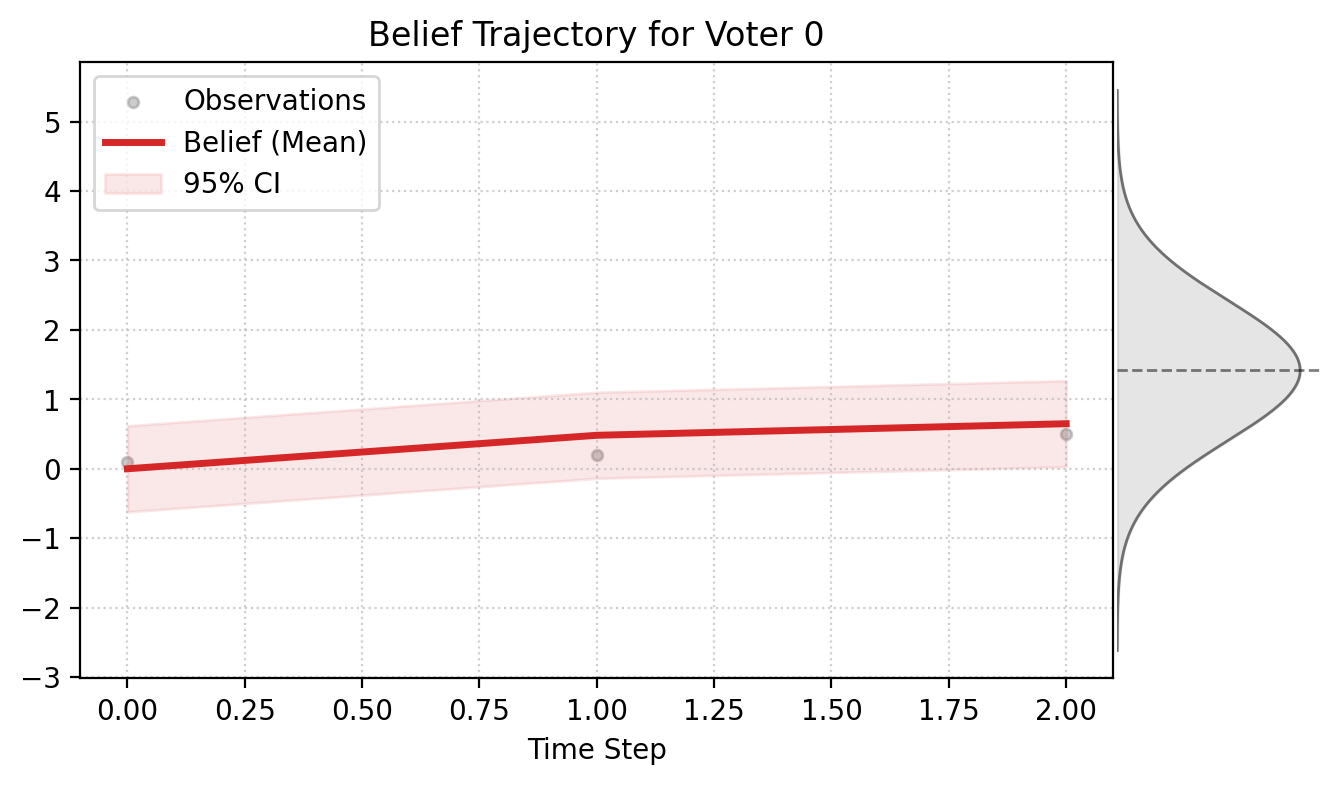

In [39]:
traj_data = get_voter_trajectory_data(env, voter_id=0)
fig, ax1, ax2 = plot_belief_trajectory(**traj_data)

# Volatility

ECI has two distinct volatilities in the model:

1. **Agent volatility** (`tonic_volatility_mean`). Each voter's *prior* on how variable the world is. Internally, this is propagated to the **X2 volatility parent** of every HGF state node — not to the state node itself. A common pitfall is to write `tonic_volatility` on `network.input_idxs` (X1), where it is silently ignored.
2. **World volatility** (`obs_dispersion`, `obs_shock_pattern`). The actual turbulence of the observation stream the agents are exposed to.

When prior matches reality, posteriors converge sharply. When they mismatch, agents are miscalibrated — and through the precision-weighted softmax, this changes how decisively they vote.


## 1. The three world regimes

`generate_observations` produces three qualitatively different signals depending on `scenario` and `shock_pattern`.

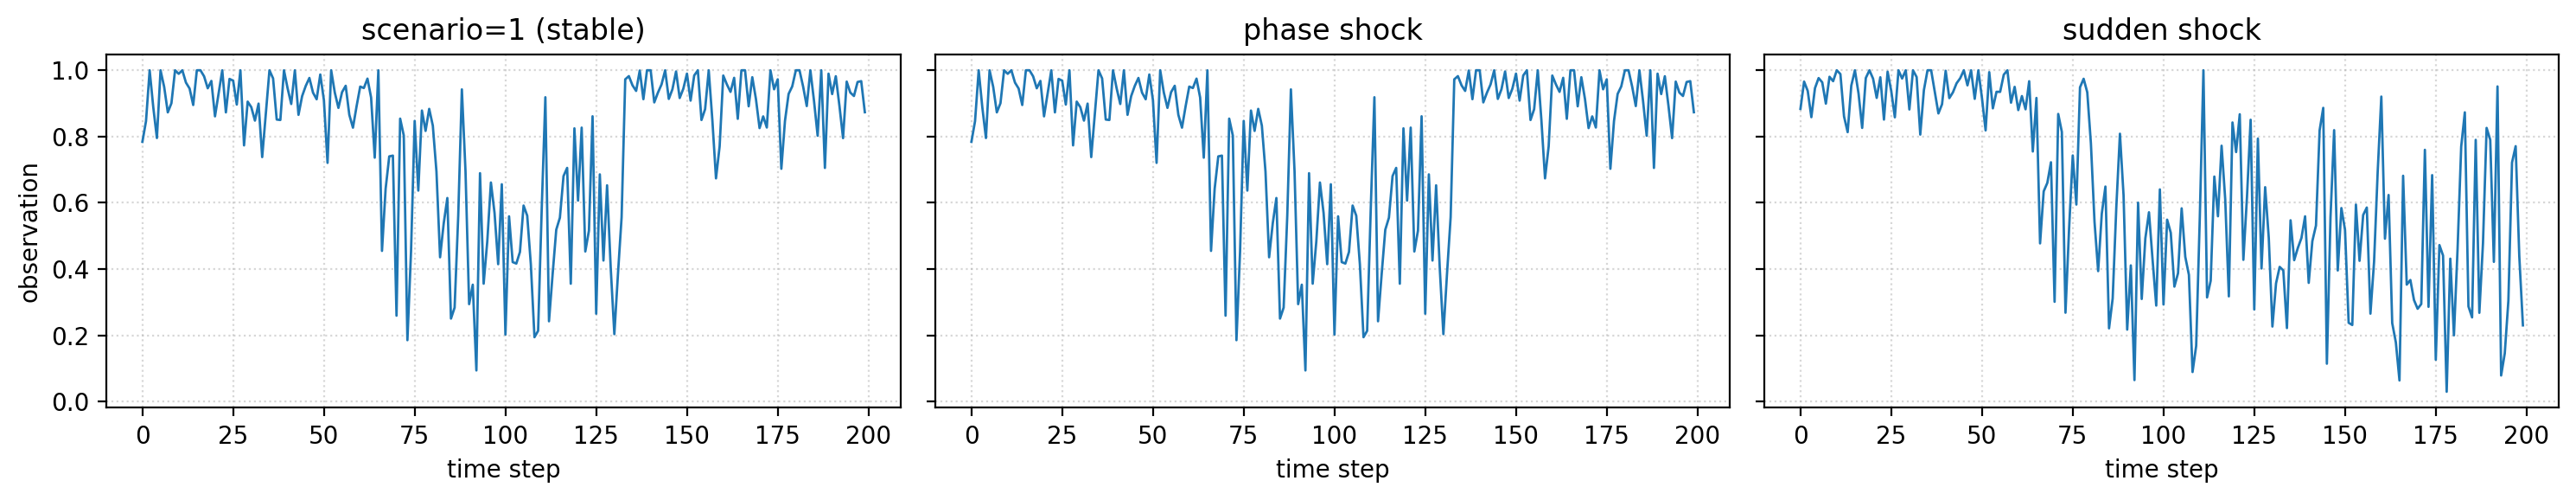

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=True)
regimes = [
    ("scenario=1 (stable)", dict(scenario=1)),
    ("phase shock", dict(scenario=2, shock_pattern="phase")),
    ("sudden shock", dict(scenario=2, shock_pattern="sudden")),
]
for ax, (label, kwargs) in zip(axes, regimes):
    obs = generate_observations(
        n_nodes=1, n_steps=200, dispersion=1.0, seed=42, **kwargs
    )
    ax.plot(obs[:, 0], lw=1, color="#1f77b4")
    ax.set_title(label)
    ax.set_xlabel("time step")
    ax.grid(True, ls=":", alpha=0.5)
axes[0].set_ylabel("observation")
plt.tight_layout()
plt.show()

## 2. Effect of `tonic_volatility` on a single agent

Two agents see the same noisy world; only their `tonic_volatility_mean` differs. Low-tvm = "I expect a stable world", high-tvm = "I expect rapid change".

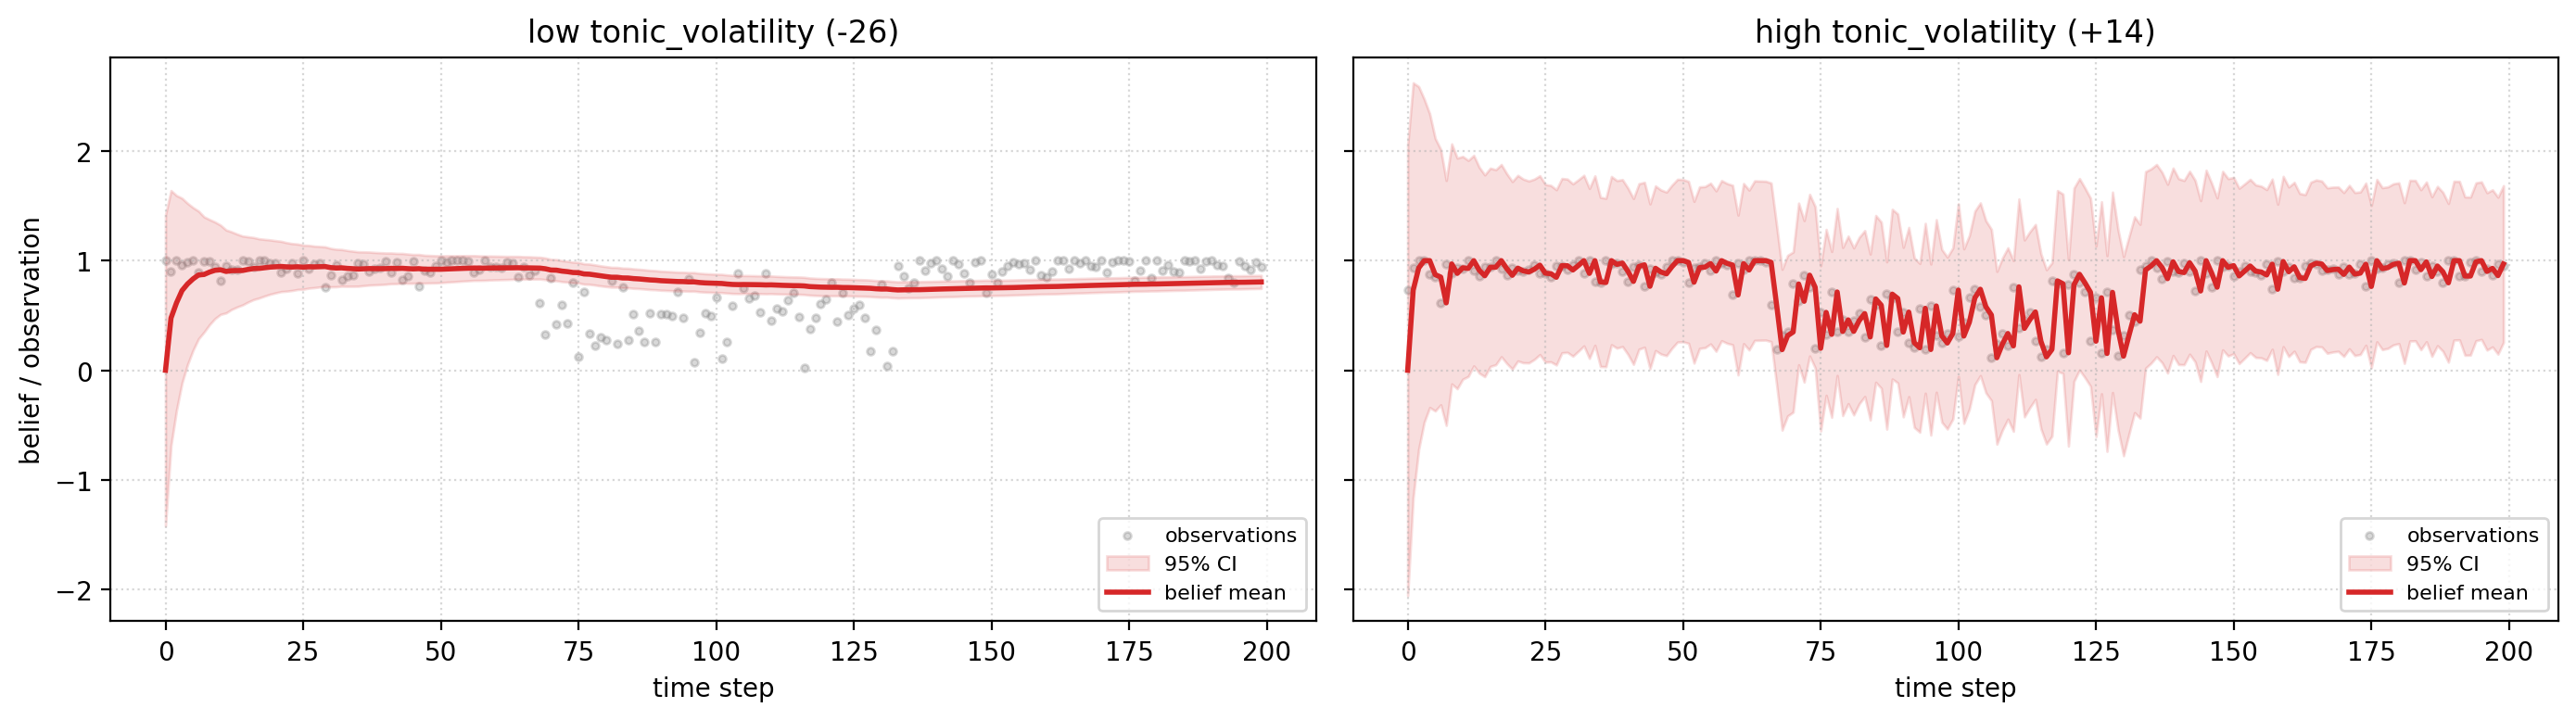

In [41]:
env_low = Environment(
    EnvConfig(
        num_voters=1,
        num_candidates=2,
        num_preferences=1,
        num_steps=200,
        scenario=1,
        tonic_volatility_mean=-26.0,
        seed=42,
    )
)
env_high = Environment(
    EnvConfig(
        num_voters=1,
        num_candidates=2,
        num_preferences=1,
        num_steps=200,
        scenario=1,
        tonic_volatility_mean=14.0,
        seed=42,
    )
)
for e in (env_low, env_high):
    e._run_multi_agent_inference()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, env, title in [
    (axes[0], env_low, "low tonic_volatility (-26)"),
    (axes[1], env_high, "high tonic_volatility (+14)"),
]:
    traj = get_voter_trajectory_data(env, voter_id=0)
    t = np.arange(len(traj["observations"]))
    mean = np.asarray(traj["expected_mean"])
    ci = 1.96 / np.sqrt(np.maximum(np.asarray(traj["precisions"]), 1e-9))
    ax.scatter(t, traj["observations"], s=8, c="gray", alpha=0.3, label="observations")
    ax.fill_between(
        t, mean - ci, mean + ci, color="#d62728", alpha=0.15, label="95% CI"
    )
    ax.plot(t, mean, color="#d62728", lw=2, label="belief mean")
    ax.set_title(title)
    ax.set_xlabel("time step")
    ax.grid(True, ls=":", alpha=0.5)
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_ylabel("belief / observation")
plt.tight_layout()
plt.show()

**Reading:** the low-tvm agent (left) keeps a wide CI band around a slow-moving belief — observations are absorbed cautiously. The high-tvm agent (right) tracks observations more aggressively and ends with a tighter CI.

## 3. The mismatch grid

The interesting regime is the **interaction** between the agent's prior and the world's volatility. We build a 2×2 grid (low/high prior × calm/noisy world).

In [42]:
priors = {"low_vol_agent": 14.0, "high_vol_agent": -26.0}
worlds = {"calm_world": 0.1, "noisy_world": 8.0}
prior_colors = {"low_vol_agent": "#1f77b4", "high_vol_agent": "#d62728"}

envs = {
    (p, w): Environment(
        EnvConfig(
            num_voters=2,
            num_candidates=2,
            num_preferences=1,
            num_steps=200,
            scenario=1,
            tonic_volatility_std=1.0,
            tonic_volatility_mean=tvm,
            seed=42,
        )
    )
    for p, tvm in priors.items()
    for w, disp in worlds.items()
}
for env in envs.values():
    env._run_multi_agent_inference()

### 3a. Belief trajectories per cell

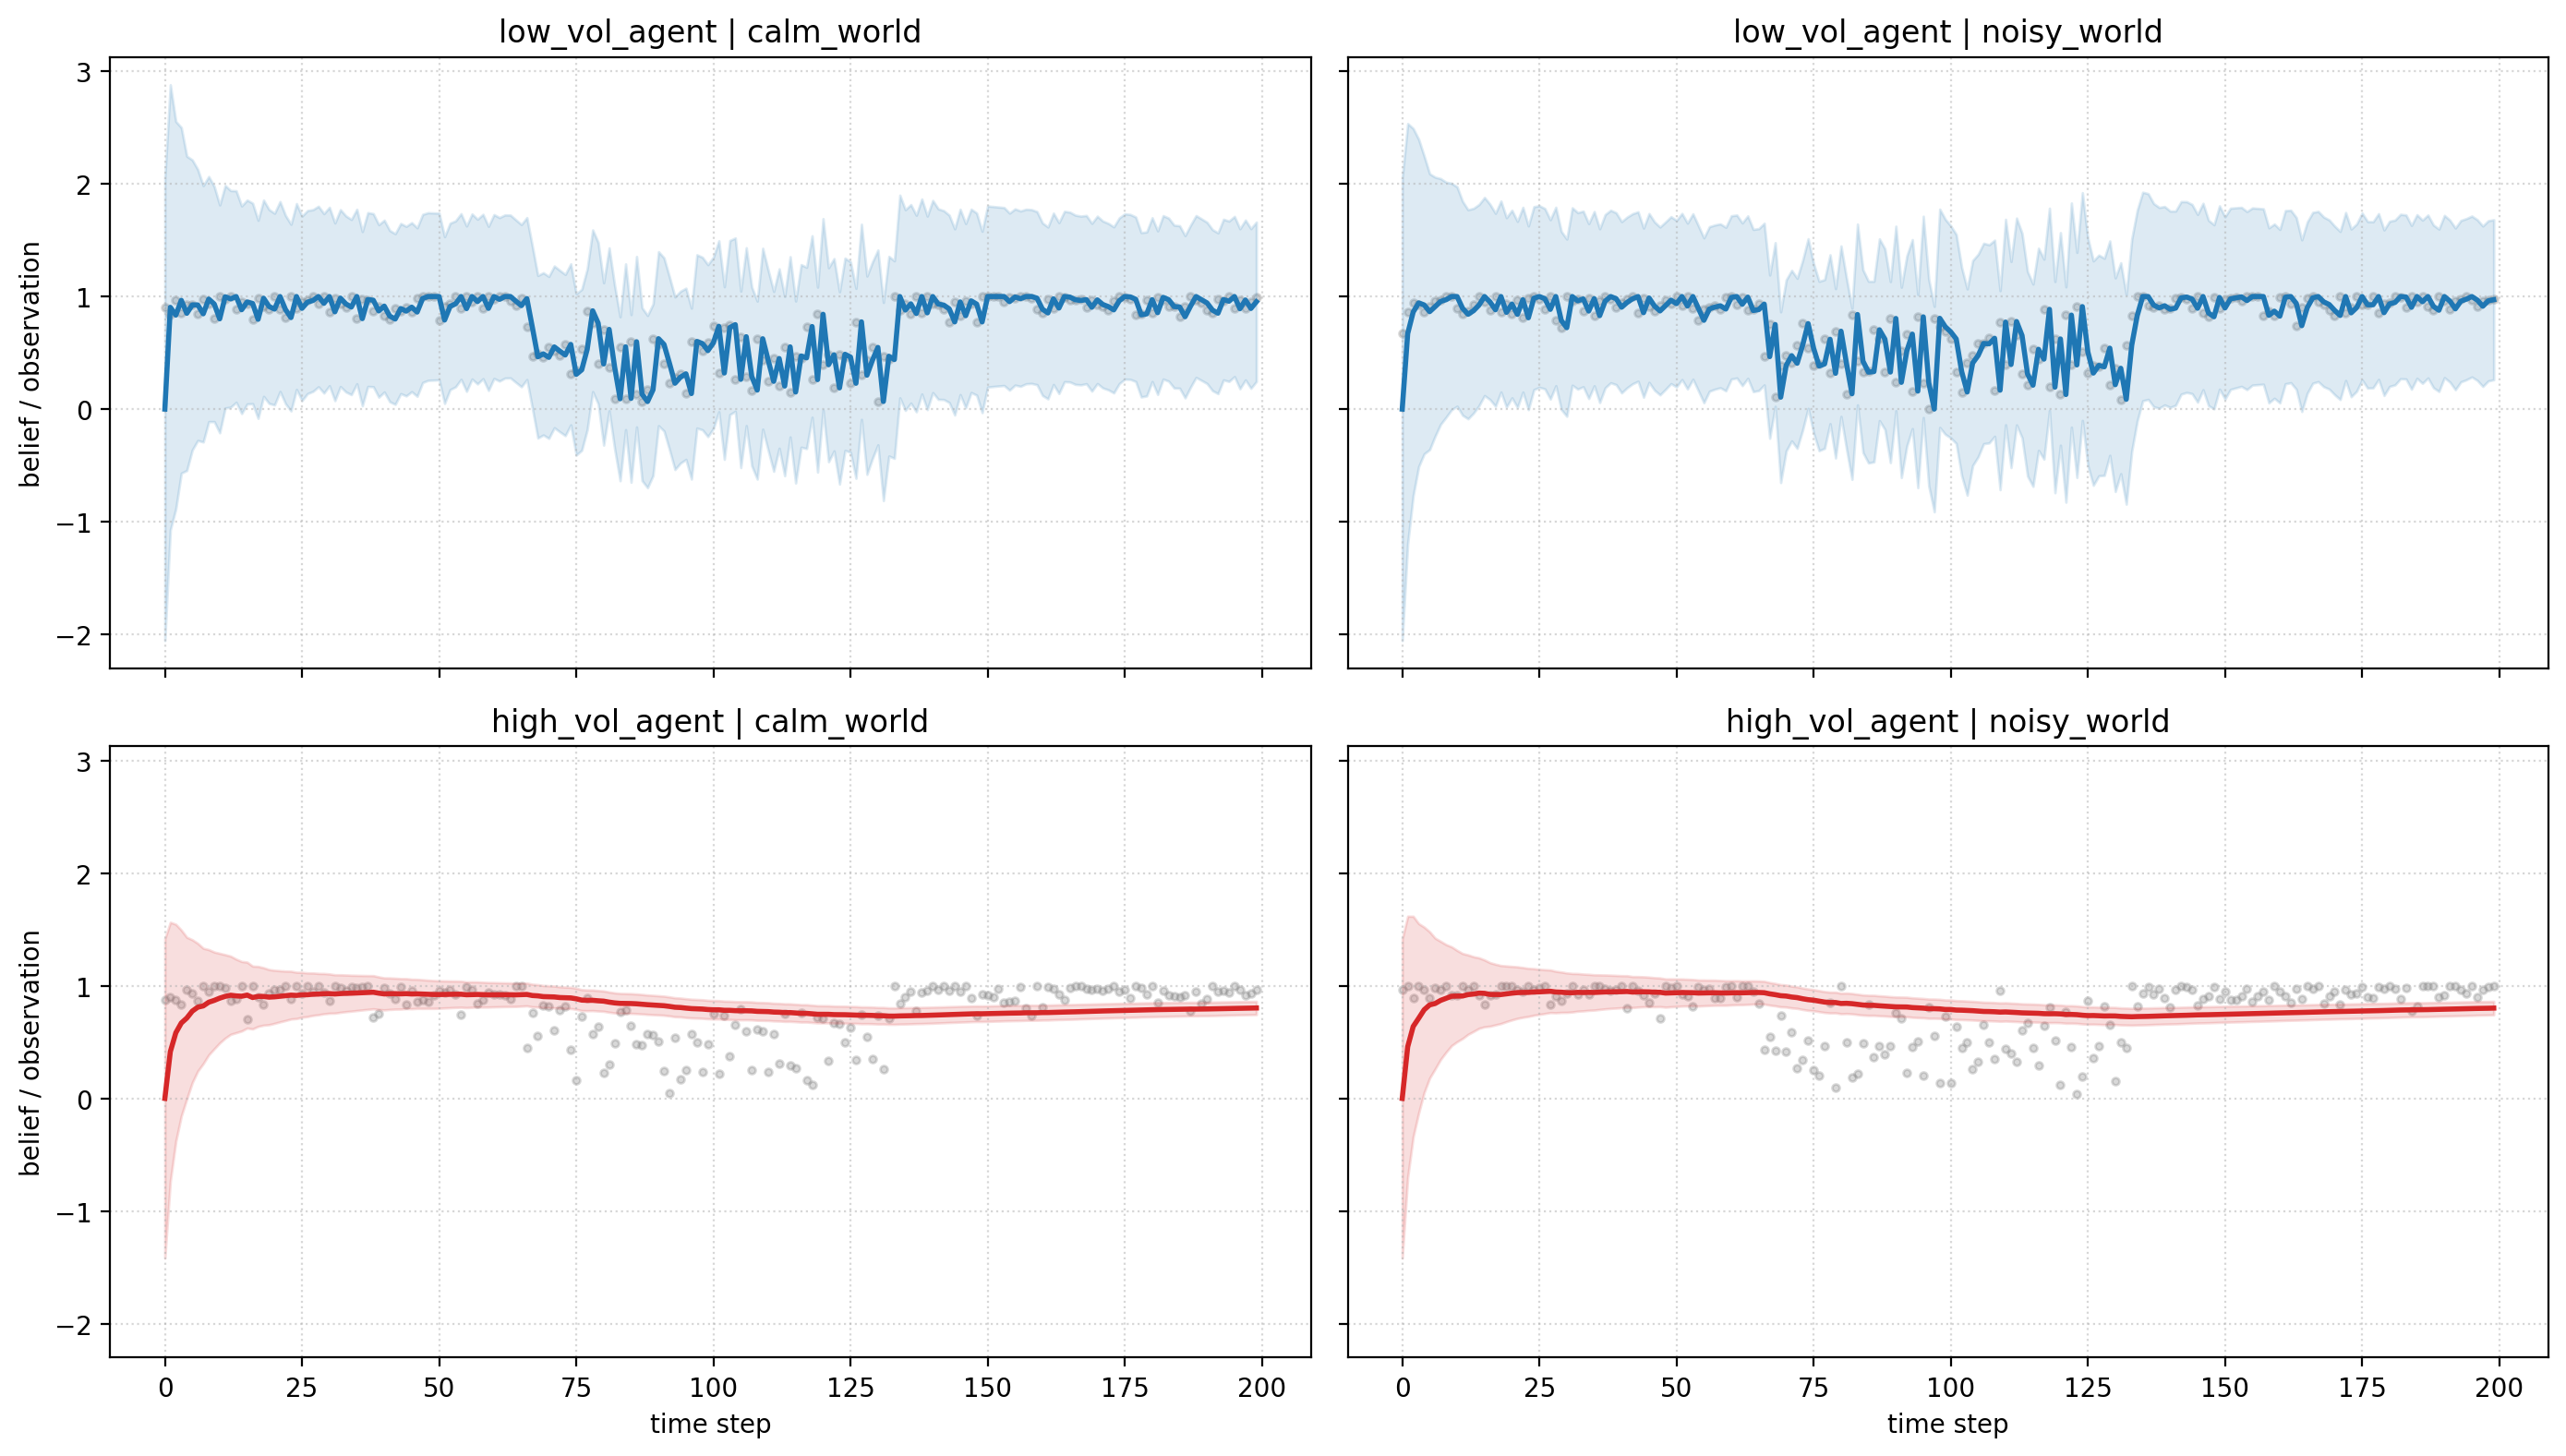

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for i, p in enumerate(priors):
    for j, w in enumerate(worlds):
        ax = axes[i, j]
        traj = get_voter_trajectory_data(envs[(p, w)], voter_id=0)
        t = np.arange(len(traj["observations"]))
        mean = np.asarray(traj["expected_mean"])
        ci = 1.96 / np.sqrt(np.maximum(np.asarray(traj["precisions"]), 1e-9))
        c = prior_colors[p]

        ax.scatter(t, traj["observations"], s=8, c="gray", alpha=0.3)
        ax.fill_between(t, mean - ci, mean + ci, color=c, alpha=0.15)
        ax.plot(t, mean, color=c, lw=2)
        ax.set_title(f"{p} | {w}")
        ax.grid(True, ls=":", alpha=0.5)

for ax in axes[-1, :]:
    ax.set_xlabel("time step")
for ax in axes[:, 0]:
    ax.set_ylabel("belief / observation")
plt.tight_layout()
plt.show()

### 3b. Posterior precision over time (where divergence shows)

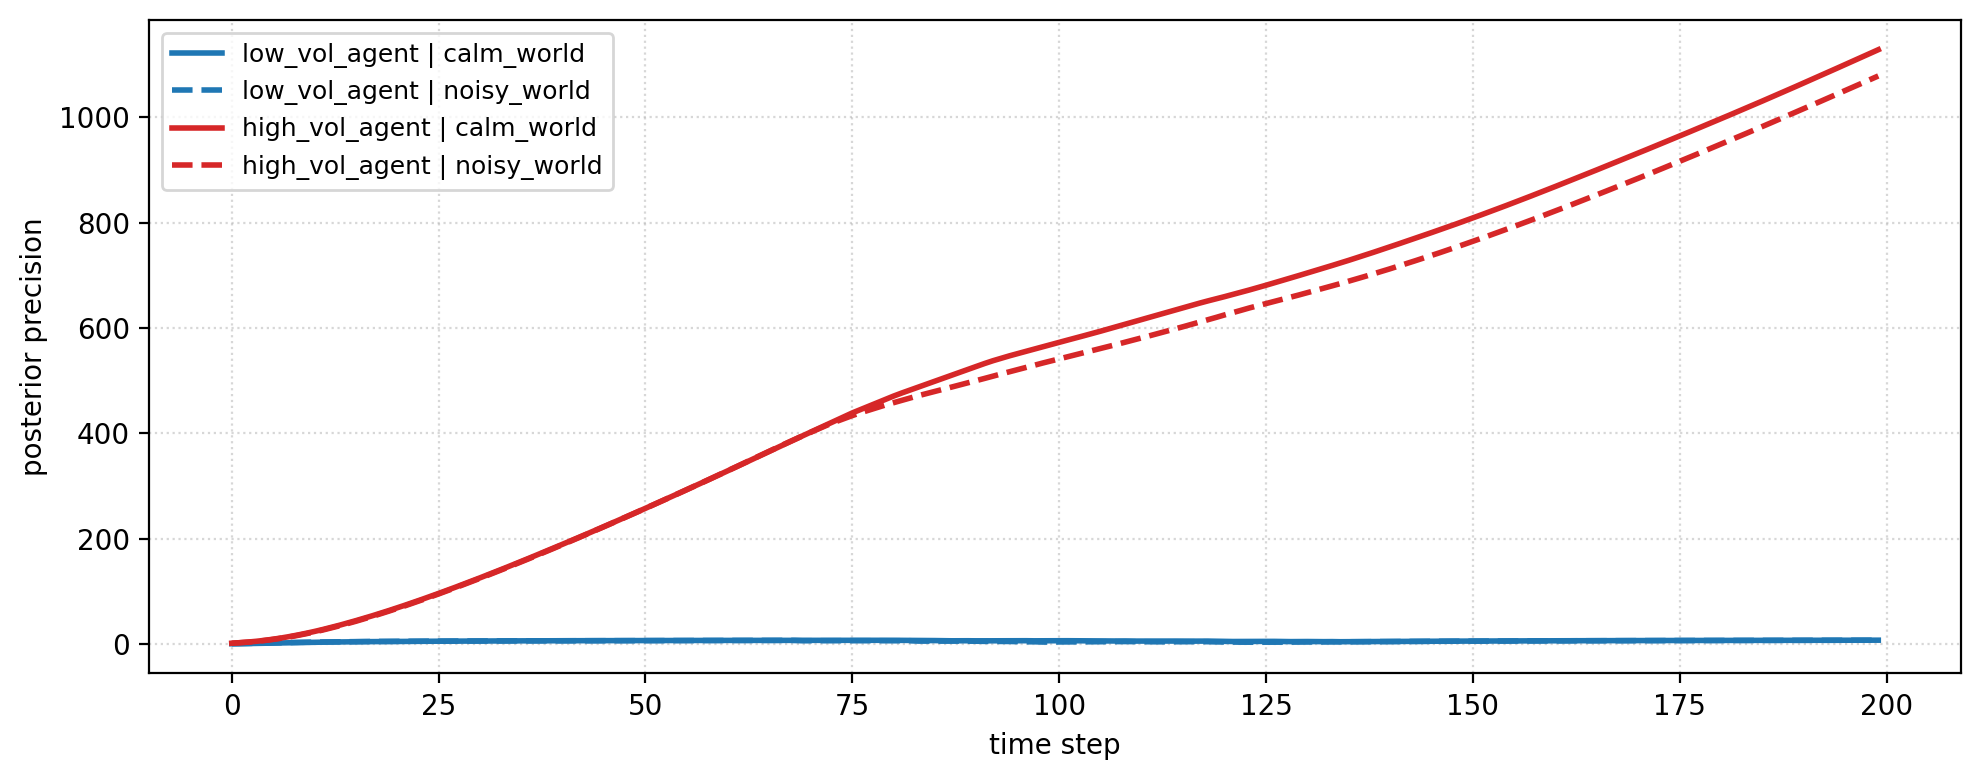

In [44]:
fig, ax = plt.subplots(figsize=(10, 4))
for (p, w), env in envs.items():
    traj = get_voter_trajectory_data(env, voter_id=0)
    style = "-" if w == "calm_world" else "--"
    ax.plot(
        traj["precisions"],
        color=prior_colors[p],
        linestyle=style,
        lw=2,
        label=f"{p} | {w}",
    )
ax.set_xlabel("time step")
ax.set_ylabel("posterior precision")
ax.legend(loc="best", fontsize=9)
ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

### 3b-bis. Diagnostic : la précision croît-elle vraiment ?

Le panel 3a montre une CI large et plate dans les 4 cellules, ce qui est attendu pour ω élevé mais **suspect** pour ω très négatif (qui devrait donner un comportement quasi-Kalman avec précision qui croît linéairement).

On imprime ici τ aux pas 0, 50, 100, 199 pour chacune des 4 cellules de la grille. Lecture :

- **Si τ croît clairement avec t pour ω = −26** → le HGF marche, la CI large vue plus haut est un effet d'échelle / de bruit obs.
- **Si τ reste plate autour de `precision_state` (=10 par défaut)** → ω = −26 ne propage pas (saturation numérique ou ω écrit au mauvais endroit).

In [52]:
env.agents[0].trajectory[0]

{'autoconnection_strength': Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float32, weak_type=True),
 'expected_mean': Array([0.        , 0.

In [46]:
diag = []
for (p, w), env in envs.items():
    traj = get_voter_trajectory_data(env, voter_id=0)
    prec = np.asarray(traj["precisions"])
    steps = [0, 50, 100, len(prec) - 1]
    row = {"agent_prior": p, "world": w}
    for s in steps:
        row[f"tau@t={s}"] = float(prec[s])
    # Width of the 95% CI at the last step, for quick sanity-check against panel 3a.
    row["ci_width@t_end"] = float(2 * 1.96 / np.sqrt(max(prec[-1], 1e-9)))
    diag.append(row)

print(pd.DataFrame(diag).round(3).to_string(index=False))

   agent_prior       world  tau@t=0  tau@t=50  tau@t=100  tau@t=199  ci_width@t_end
 low_vol_agent  calm_world    0.909     7.005      6.635      7.659           1.416
 low_vol_agent noisy_world    0.909     7.023      4.332      7.608           1.421
high_vol_agent  calm_world    1.909   257.873    572.688   1128.047           0.117
high_vol_agent noisy_world    1.909   257.779    541.482   1078.246           0.119


### 3c. End-of-trajectory summary

In [47]:
summary = []
for (p, w), env in envs.items():
    data = _extract_env_data_vectorized(env)
    summary.append(
        {
            "agent_prior": p,
            "world": w,
            "final_posterior_precision": float(
                jnp.sum(data["beliefs"]["precision"], axis=-1)[0]
            ),
            "pref_belief_gap": float(
                _get_belief_preference_gap(
                    data["beliefs"]["mean"],
                    data["beliefs"]["precision"],
                    data["preferences"]["mean"],
                    data["preferences"]["precision"],
                )[0]
            ),
        }
    )
print(pd.DataFrame(summary).round(3).to_string(index=False))

   agent_prior       world  final_posterior_precision  pref_belief_gap
 low_vol_agent  calm_world                      7.659            0.732
 low_vol_agent noisy_world                      7.608            0.727
high_vol_agent  calm_world                      7.074            0.725
high_vol_agent noisy_world                      6.948            0.717


**Reading the grid:** the diagonal (matched prior and world) tends to produce sharp posteriors and small `pref_belief_gap`. The off-diagonal is *miscalibrated* — wide posteriors, large dissatisfaction. This is the active-inference signature of model mis-specification.

## 4. From beliefs to votes

ECI's voting score is a **precision-weighted softmax**:

$$\text{score}_{i,c} = -\,\tau_i \cdot D_{\text{KL}}(\kappa_c \,\|\, \pi_i)$$

where $\tau_i$ is voter $i$'s posterior precision (sum across preference dimensions), $\kappa_c$ is candidate $c$'s policy, and $\pi_i$ is voter $i$'s preference. The vote distribution is then $\text{softmax}(\text{score}_{i,:})$.

A high-$\tau$ voter has a sharp softmax and votes decisively. A low-$\tau$ voter has a near-uniform softmax — effectively abstains. The **entropy** of the vote distribution is a clean way to summarize this.

In [48]:
results = []
for (p, w), env in envs.items():
    data = _extract_env_data_vectorized(env)
    tau = jnp.sum(data["beliefs"]["precision"], axis=-1)
    gap = _get_pref_candidate_gap(
        data["preferences"]["mean"],
        data["preferences"]["precision"],
        data["candidates"]["mean"],
        data["candidates"]["precision"],
    )
    probs = jax.nn.softmax(-tau[:, None] * gap, axis=1)
    H = float(entropy(np.asarray(probs[0])))
    results.append(
        {
            "agent_prior": p,
            "world": w,
            "posterior_precision": float(tau[0]),
            "vote_entropy": H,
        }
    )
print(pd.DataFrame(results).round(3).to_string(index=False))

   agent_prior       world  posterior_precision  vote_entropy
 low_vol_agent  calm_world                7.659         0.538
 low_vol_agent noisy_world                7.608         0.540
high_vol_agent  calm_world                7.074         0.557
high_vol_agent noisy_world                6.948         0.562


**Reading:** higher `posterior_precision` produces lower `vote_entropy` (sharper vote). Calibrated voters drive the collective decision because their votes carry more information; miscalibrated voters effectively abstain.

## Take-away

- Posterior precision — the agent's confidence after HGF inference — is what the precision-weighted softmax reads.
- **Calibrated** voters (matched prior + world) have sharp posteriors and vote decisively.
- **Miscalibrated** voters have diffuse posteriors and vote almost uniformly.
- The next tutorial sweeps this 2D grid across 30 seeds and 1000 voters to measure how miscalibration biases collective outcomes under plurality vs quadratic voting.

This is the predictive-coding analog of intensity-weighted aggregation: what looks like "intense voters dominating" at the population level is, mechanistically, just precision-weighted softmax composition.
